In [44]:
import pandas as pd
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error

df3=pd.read_csv(r'c:\Users\chandugowda\Downloads\Bengaluru_House_Data (1).csv')

In [45]:
df3.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [46]:
df3=df3.drop(['area_type','balcony','society','availability'],axis=1)
df3.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [47]:
df3.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [48]:
df3["location"].value_counts()


location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [49]:
df3["location"]=df3["location"].fillna("Sarjapur  Road")
df3["location"].value_counts()

location
Whitefield                                         540
Sarjapur  Road                                     400
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [50]:
med_bath=df3["bath"].median()
med_bath
df3["bath"]=df3["bath"].fillna(med_bath)

In [51]:
df3["bath"]=df3["bath"].astype(int)
df3["bath"].unique()

array([ 2,  5,  3,  4,  6,  1,  9,  8,  7, 11, 10, 14, 27, 12, 16, 40, 15,
       13, 18])

In [52]:
df3.drop_duplicates(inplace=True)

In [53]:
df3["location"].value_counts()

location
Whitefield                                         507
Sarjapur  Road                                     365
Electronic City                                    273
Thanisandra                                        224
Kanakpura Road                                     223
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [54]:
df3["location"] = df3["location"].apply(lambda x:x.strip())

loc = df3['location'].value_counts()
loc_lthan_10 = loc[loc <= 10]

df3['location'] = df3['location'].apply(lambda x: 'other' if x in loc_lthan_10 else x)


df3['location'].value_counts()

location
other                   2927
Whitefield               508
Sarjapur  Road           365
Electronic City          275
Thanisandra              226
                        ... 
NGR Layout                11
Doddakallasandra          11
Banashankari Stage V      11
Thyagaraja Nagar          11
HAL 2nd Stage             11
Name: count, Length: 232, dtype: int64

In [55]:
df3['size']=df3['size'].fillna('2 BHK')

In [56]:
df3['size'].value_counts()

out=[int(i.split()[0])for i in df3['size']]

df3['bhk']=out
df3

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,other,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [57]:
def clean_sqft(sqft):
    li=sqft.split('-')
    try:
        if len(li)==2:
            return(float(li[0]) + float(li[1]))/2
        else:
            return float(li[0])
    
    except:
        return None

df3['total_sqft']=df3['total_sqft'].apply(clean_sqft)
df3["total_sqft"]=df3["total_sqft"].fillna(round(df3["total_sqft"].mean()))

In [58]:
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
bhk           0
dtype: int64

In [59]:
df3

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4
2,Uttarahalli,3 BHK,1440.0,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3
4,Kothanur,2 BHK,1200.0,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5
13316,other,4 BHK,3600.0,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2


In [60]:
df3["price_per_sqft"]=df3["price"]*100000/df3["total_sqft"]
df3

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,other,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [61]:
df3=df3[df3['total_sqft']/df3['bhk']>=300]

In [62]:
df3.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,11705.000000,11705.000000,11705.000000,11705.000000,11705.000000
mean,1614.029039,2.579667,114.455648,2.666809,6405.091922
std,1296.481391,1.099383,156.421987,0.995743,4281.960473
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1120.000000,2.000000,50.000000,2.000000,4253.521127
50%,1314.000000,2.000000,71.000000,3.000000,5348.837209
75%,1720.000000,3.000000,120.000000,3.000000,7000.000000
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [63]:
df3=df3[df3["bhk"]<=6]

In [64]:
df3=df3[df3["bath"]<df3["bhk"]+2]
df3

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,other,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


<Axes: xlabel='price_per_sqft'>

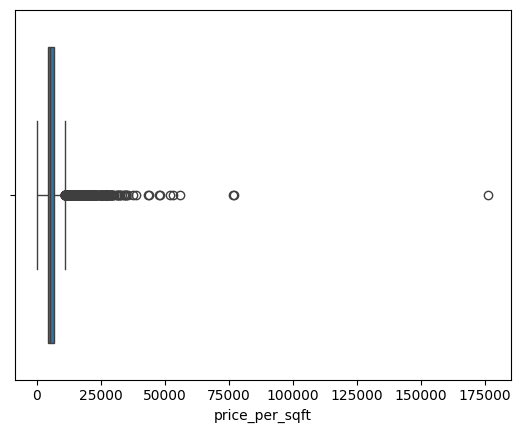

In [65]:
sns.boxplot(x="price_per_sqft",data=df3)

<Axes: xlabel='price_per_sqft'>

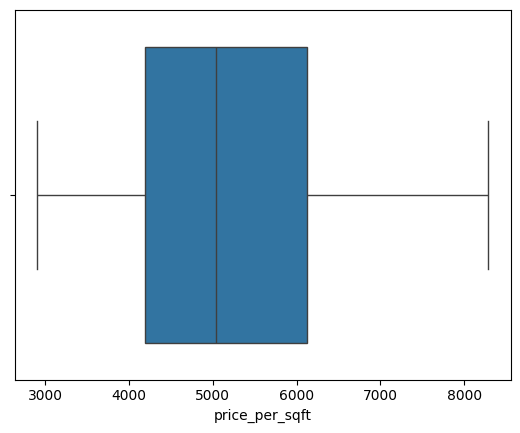

In [66]:
q1=df3['price_per_sqft'].quantile(0.25)
q2=df3['price_per_sqft'].quantile(0.75)

iqr=q2-q1

lower=q1-0.5*iqr
upper=q2+0.5*iqr

df3=df3[(df3['price_per_sqft']>=lower) & (df3["price_per_sqft"]<=upper)]

sns.boxplot(x='price_per_sqft',data=df3)

In [67]:
df3.reset_index(inplace=True)
df3

,index,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...,...
9356,13310,Rachenahalli,2 BHK,1050.0,2,52.71,2,5020.000000
9357,13312,Bellandur,2 BHK,1262.0,2,47.00,2,3724.247227
9358,13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
9359,13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926


In [68]:
df3=df3.drop(["index","size"],axis=1)
df3

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3,95.00,3,6245.890861
4,Kothanur,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...
9356,Rachenahalli,1050.0,2,52.71,2,5020.000000
9357,Bellandur,1262.0,2,47.00,2,3724.247227
9358,Green Glen Layout,1715.0,3,112.00,3,6530.612245
9359,Whitefield,3453.0,4,231.00,5,6689.834926


In [69]:
df3=pd.get_dummies(df3,columns=['location'],drop_first=True,dtype=int)

In [70]:
df3.columns

Index(['total_sqft', 'bath', 'price', 'bhk', 'price_per_sqft',
       'location_1st Phase JP Nagar', 'location_2nd Stage Nagarbhavi',
       'location_5th Block Hbr Layout', 'location_5th Phase JP Nagar',
       'location_6th Phase JP Nagar',
       ...
       'location_Vishveshwarya Layout', 'location_Vishwapriya Layout',
       'location_Vittasandra', 'location_Whitefield',
       'location_Yelachenahalli', 'location_Yelahanka',
       'location_Yelahanka New Town', 'location_Yelenahalli',
       'location_Yeshwanthpur', 'location_other'],
      dtype='str', length=235)

In [71]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df3)

In [72]:
X=df3.drop(["price",'price_per_sqft'],axis=1)
y=df3.price

In [73]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.3,random_state=42)

In [74]:
model=RandomForestRegressor(random_state=42)
params={
    "n_estimators":[100,150,200],
    "max_depth":[3,4,5,6,7]
}

grid= GridSearchCV(estimator=model,param_grid=params,cv=5)

grid.fit(Xtrain,ytrain)

print("Best params:",grid.best_params_)
print("Best score:",grid.best_score_)

Best params: {'max_depth': 7, 'n_estimators': 200}
Best score: 0.8424759278316063


In [75]:
df3.shape

(9361, 235)

In [76]:
best_model=grid.best_estimator_

In [77]:
ypred=grid.predict(Xtest)
ypred

array([81.31692943, 60.33755385, 69.19455582, ..., 71.10576544,
       60.37809717, 63.05690767], shape=(2809,))

In [78]:
print("training Eff:",grid.score(Xtrain,ytrain))
print("testing Eff:",grid.score(Xtest,ytest))

training Eff: 0.9062497855419118
testing Eff: 0.8118045255715314


In [79]:
print("R2",r2_score(ytest,ypred))
print("MAE:",mean_absolute_error(ytest,ypred))

R2 0.8118045255715314
MAE: 14.097379104111923


In [80]:
df3.to_csv("cleaned_df3.csv")

In [81]:
joblib.dump(best_model,'rd_modle.joblip')

['rd_modle.joblip']

In [85]:
joblib.dump(Xtrain.columns.tolist(),"model_columns.joblib")

['model_columns.joblib']